# Hyper-parameter Tuning in SVM: 8x8 Handwritten Digit Recognition
Import libraries, then load data set.

In [1]:
# imports
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np
import random

(1797, 64)


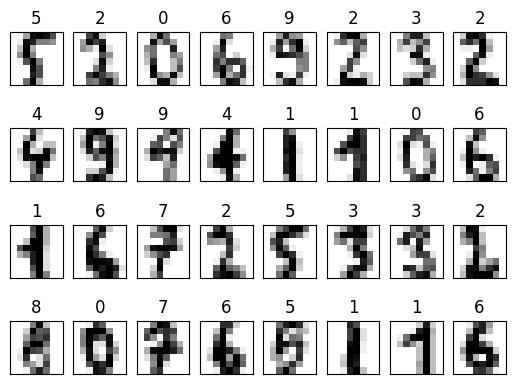

In [2]:
# loading data then inspecting it
X, y = load_digits(return_X_y=True)
print(X.shape)
random.seed(0)

# creating a 4x8 grid of images
rows, cols = 4, 8
fig, ax = plt.subplots(rows, cols, sharex='col', sharey='row',
                       subplot_kw=dict(xticks=[], yticks=[]))

for row in range(rows):
    for col in range(cols):
        n = np.random.randint(1796)+1    # show random samples
        im = ax[row, col].imshow(X[n].reshape((8,8)), cmap=plt.cm.binary)
        ax[row, col].set_title(y[n])
        im.set_clim(0, 16)
        #print(X[n])

plt.show()

Import libraries for hyperparameter search

In [3]:
from sklearn.svm import SVC # for implementation of SVC
from time import time # for timing of hyperparameter search 
from sklearn.model_selection import train_test_split # for data splitting
from sklearn.model_selection import cross_val_score # for evaluating cross-validation
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV # for implementation of hyperparameter search
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report # for evaluation

## Grid Search the Best SVM

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=

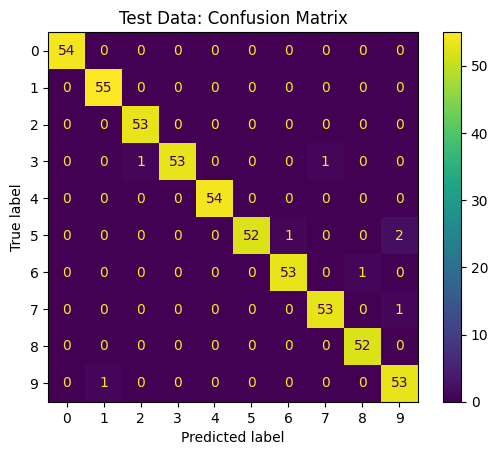

In [4]:
# specify the grid: parameters and values
param_grid = {'C': [0.1, 1, 10, 100, 1000], 
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf','linear','poly','sigmoid']} 

# split the data  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

# creating a grid search object; 
# specifying the estimator, hyperparameters to choose from, whether we want to refit to the entire training data using best parameters, and amount of verbosity
grid_search = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)

# fitting grid search
start = time() # start of timing
grid_search.fit(X_train, y_train) # fitting to training data and looking for best hyperparameters
print("GridSearchCV took %.2f seconds for %d candidate parameter settings."
      % (time() - start, len(grid_search.cv_results_["params"])))

# printing best parameters after tuning
print(f"Best parameters: {grid_search.best_params_}")
  
# printing how our model looks after hyperparameter tuning
print(f"Best estimator: {grid_search.best_estimator_}")

# predicting using the best hyperparameters
grid_predictions = grid_search.predict(X_test)
  
# printing classification report
print(classification_report(y_test, grid_predictions))

# evaluating the best model
cfm = confusion_matrix(y_test, grid_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cfm, display_labels = np.arange(0,10))
cm_display.plot()
plt.title('Test Data: Confusion Matrix')
plt.show()

True: 5, Predicted: 9


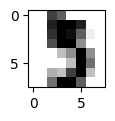

True: 7, Predicted: 9


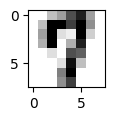

True: 9, Predicted: 1


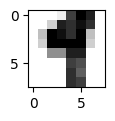

True: 5, Predicted: 6


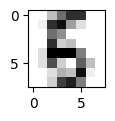

True: 3, Predicted: 7


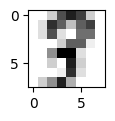

True: 6, Predicted: 8


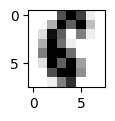

True: 3, Predicted: 2


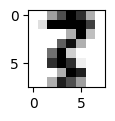

True: 5, Predicted: 9


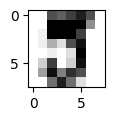

In [5]:
# displaying misclassified samples, if any
mis = np.where(y_test != grid_predictions)

for i in mis[0]:
    plt.figure(figsize=(2, 1))
    im = plt.imshow(X_test[i].reshape((8,8)), cmap=plt.cm.binary)
    print(f"True: {y_test[i]}, Predicted: {grid_predictions[i]}")
    im.set_clim(0, 16)
    plt.show()

## Random Search the Best SVM

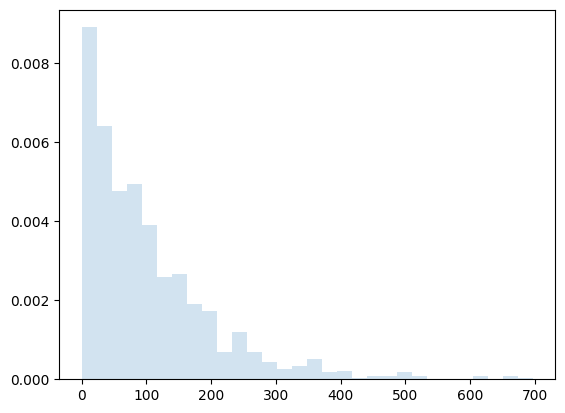

In [6]:
import scipy.stats as stats

# to get a feel for the exponential distribution (to be used for generator C and gamma hyperparameter options)
random_C = stats.expon.rvs(scale=100,size=1000)
fig, ax = plt.subplots(1, 1)
ax.hist(random_C, density=True, bins='auto', histtype='stepfilled', alpha=0.2)
plt.show()

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[CV] END C=28.792040029246646, gamma=0.208499634549292, kernel=poly; total time=   0.0s
[CV] END C=28.792040029246646, gamma=0.208499634549292, kernel=poly; total time=   0.0s
[CV] END C=28.792040029246646, gamma=0.208499634549292, kernel=poly; total time=   0.0s
[CV] END C=28.792040029246646, gamma=0.208499634549292, kernel=poly; total time=   0.0s
[CV] END C=28.792040029246646, gamma=0.208499634549292, kernel=poly; total time=   0.0s
[CV] END C=54.762245130906315, gamma=0.3694117911641573, kernel=sigmoid; total time=   0.0s
[CV] END C=54.762245130906315, gamma=0.3694117911641573, kernel=sigmoid; total time=   0.0s
[CV] END C=54.762245130906315, gamma=0.3694117911641573, kernel=sigmoid; total time=   0.0s
[CV] END C=54.762245130906315, gamma=0.3694117911641573, kernel=sigmoid; total time=   0.0s
[CV] END C=54.762245130906315, gamma=0.3694117911641573, kernel=sigmoid; total time=   0.0s
[CV] END C=226.04071298652903, gamma=0.0806612776228939, kernel=sigmoid; total time=   0.0s
[CV] END

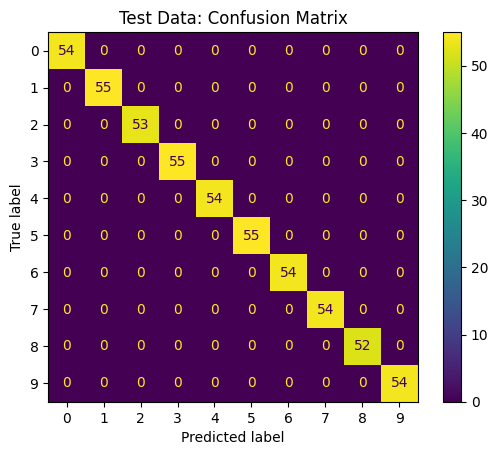

In [7]:
# specifying the hyperparameter options
param_dist = {'C': stats.expon(scale=100), 
              'gamma': stats.expon(scale=.1),
              'kernel': ['rbf','linear','poly','sigmoid']}

# creating a random search object; 
# specifying the estimator, hyperparameters to choose from, number of iterations, and amount of verbosity
max_iter = 20
random_search = RandomizedSearchCV(SVC(), param_distributions=param_dist, n_iter=max_iter, verbose=2)

# fitting random search
start = time() # start of timing
random_search.fit(X, y) # fitting to training data and looking for best hyperparameters
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
        % ((time() - start), max_iter))

# printing best parameters after tuning
print(f"Best parameters: {random_search.best_params_}")
  
# printing how our model looks after hyper-parameter tuning
print(f"Best estimator: {random_search.best_estimator_}")

# predicting using the best hyperparameters
random_predictions = random_search.predict(X_test)
  
# printing classification report
print(classification_report(y_test, random_predictions))

# evaluating the best model
cfm = confusion_matrix(y_test, random_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cfm, display_labels = np.arange(0,10))
cm_display.plot()
plt.title('Test Data: Confusion Matrix')
plt.show()

In [8]:
# displaying misclassified samples, if any
mis = np.where(y_test != random_predictions)

for i in mis[0]:
    plt.figure(figsize=(2, 1))
    im = plt.imshow(X_test[i].reshape((8,8)), cmap=plt.cm.binary)
    print(f"True: {y_test[i]}, Predicted: {random_predictions[i]}")
    im.set_clim(0, 16)
    plt.show()

There is no display for misclassifications since, looking at the confusion matrix, there is indeed no misclassified samples.